In [6]:
%load_ext autoreload
%autoreload 2

import sys
import os
# Agrega el directorio padre (la raíz del repositorio) al path temporal de Python
sys.path.append(os.path.abspath(os.path.join('..')))

import numpy as np
import matplotlib.pyplot as plt

from src.helpers.data_loader import load_image
from src.fringe_fraction_measurement import FringeFractionMeasurement
from src.mefm_solver import MonochromaticEFMSolver
from src.refraction_index import EdlenRefractiveIndex

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Input data

# Interferogram loading



# Wavelenght
vacuum_wavelength = 633 # nm
vacuum_wavelength_um = vacuum_wavelength / 1000 # [um]


# Gauge block information known in advance 
nominal_length_ = 100.0          # [mm]
delta_nominal_length_ = -60.0    # Tomado de certificado
uncertainty_ = 90.0              # (0.03 + (6e-4)*100)*1e3 # nm | Tomado de certificado

# Environmental conditions
air_temperature = 20             # °C
atmospheric_pressure = 75000     # Pa
air_humidity = 50                # %







In [8]:
# Correción indice de refración y longitud de onda en aire
env = EdlenRefractiveIndex(temperature=air_temperature, pressure=atmospheric_pressure, relative_humidity=air_humidity)
index_refraction = env.index_refraction(vacuum_wavelength_um)
wavelength_air = env.wavelength_in_air(vacuum_wavelength_um) # [um]

print(f"Refractive index of air: {index_refraction:.9f}")
print(f"Wavelength in air: {wavelength_air*1e3:.6f} nm")

Refractive index of air: 1.000200738
Wavelength in air: 632.872959 nm


In [9]:
# Fringe fraction computation
img_label = "block_100.0001582_mm(simulated).png"
img = load_image(img_label)

roi_platina = (700, 1900, 500, 900)  # (yp1, yp2, xp1, xp2)
roi_bloque  = (700, 1900, 1000, 1400) # (yb1, yb2, xb1, xb2)

medicion = FringeFractionMeasurement(img, roi_platina, roi_bloque)
medicion.fit()
medicion.calculate_fraction()
fraction = medicion.fraccion_fase           # <--- Desire fringe fraction
print(f"Fracción de franja medida: {fraction:.4f}")


--- QUALITY REPORT: Platina ---
R^2                 : 0.9973
RMSE                : 4.56 intensity units
Phase Uncertainty   : +/- 0.0030 radians
----------------------------------------
--- QUALITY REPORT: Bloque ---
R^2                 : 0.9973
RMSE                : 4.54 intensity units
Phase Uncertainty   : +/- 0.0031 radians
----------------------------------------
Fase Platina: 5.227 rad
Fase Bloque:  1.219 rad
Fracción de Franja (f = a/b): 0.3621
Fracción de franja medida: 0.3621


In [26]:
# Excess fraction computation ("real" length with no corrections)
he_ne_laser = MonochromaticEFMSolver(wavelength=wavelength_air * 1e3) # entra lambda en nm
# he_ne_laser = MonochromaticEFMSolver(wavelength=632.87)

# Evaluate the 100 mm block with the mechanical and optical data
try:
    result = he_ne_laser.evaluate_block(
        nominal_length=100e6,           
        delta_nominal_length=-60.0,  # Tomado de certificado
        uncertainty=90.0,            # (0.03 + (6e-4)*100)*1e3 # nm | Tomado de certificado  
        measured_fraction=0.3908     # valor obtenido por el script para bloque de 100.0 mm
    )
        
    print("Calibration Results:")
    print("-" * 20)
    print(f"Input wavelength:   {632.87} nm")
    print(f"Real Length:        {result['real_length_nm']:.3f} nm")
    print(f"Accepted c_j value: {result['c_difference_nm']} nm")
    print(f"Acceptance bounds:  {result['acceptance_interval']}")

except ValueError as e:
    print(f"Method Error: {e}")
except RuntimeError as e:
    print(f"Logic Error: {e}")

c_difference_nm: [-1518.75855702 -1202.32207769  -885.88559836  -569.44911903
  -253.01263971    63.42383962   379.86031895   696.29679827
  1012.7332776   1329.16975693  1645.60623626] - Bounds (-150.0, 30.0)
Logic Error: Convergence failure: No optical value matches the mechanical measurement.


In [57]:
wls = np.linspace(632, 633 ,100)
length_real = []

for wl in wls:
    he_ne_laser = MonochromaticEFMSolver(wavelength=wl)
    result = he_ne_laser.evaluate_block(
            nominal_length=100e6,           
            delta_nominal_length=-60.0,  # Tomado de certificado
            uncertainty=90.0,            # (0.03 + (6e-4)*100)*1e3 # nm | Tomado de certificado  
            measured_fraction=0.3908     # valor obtenido por el script para bloque de 100.0 mm
    )
    
    if result:
        length_real.append(result['real_length_nm'])
                
        print("Calibration Results:")
        print("-" * 20)
        print(f"Input wavelength:   {wl} nm")
        print(f"Real Length:        {result['real_length_nm']:.3f} nm")
        print(f"Accepted c_j value: {result['c_difference_nm']} nm")
        print(f"Acceptance bounds:  {result['acceptance_interval']}")
    else:
        length_real.append(result)
        print(f"Input wavelength:   {wl} nm")
        

    # except ValueError as e:
    #     length_real.append(0)
    #     print(f"Input wavelength:   {wl} nm")
    #     print(f"Method Error: {e}")
    # except RuntimeError as e:
    #     print(f"Logic Error: {e}")

Calibration Results:
--------------------
Input wavelength:   632.0 nm
Real Length:        99999903.493 nm
Accepted c_j value: -96.50719999557623 nm
Acceptance bounds:  (-150.0, 30.0)
Calibration Results:
--------------------
Input wavelength:   632.010101010101 nm
Real Length:        99999921.727 nm
Accepted c_j value: -78.27290303370525 nm
Acceptance bounds:  (-150.0, 30.0)
Calibration Results:
--------------------
Input wavelength:   632.020202020202 nm
Real Length:        99999939.911 nm
Accepted c_j value: -60.089111115273845 nm
Acceptance bounds:  (-150.0, 30.0)
Calibration Results:
--------------------
Input wavelength:   632.030303030303 nm
Real Length:        99999958.044 nm
Accepted c_j value: -41.95582424329119 nm
Acceptance bounds:  (-150.0, 30.0)
Calibration Results:
--------------------
Input wavelength:   632.040404040404 nm
Real Length:        99999976.127 nm
Accepted c_j value: -23.873042420610037 nm
Acceptance bounds:  (-150.0, 30.0)
Calibration Results:
-------------

In [59]:
length_real

[np.float64(99999903.4928),
 np.float64(99999921.72709696),
 np.float64(99999939.91088888),
 np.float64(99999958.04417576),
 np.float64(99999976.12695758),
 np.float64(99999994.15923434),
 np.float64(100000012.14100605),
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 np.float64(99999855.62846665),
 np.float64(99999873.10013738),
 np.float64(99999890.52130303),
 np.float64(99999907.89196363),
 np.float64(99999925.21211919),
 np.float64(99999942.48176971),
 np.float64(99999959.70091516),
 np.float64(99999976.86955555),
 np.float64(99999993.98769091),
 np.float64(100000011.05532122),
 np.float64(100000028.07244647),
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 np.float64(99999862.78212929),
 np.float64(99999879.28915353),
 np.float64(99999895.74567273),
 np.float64(99999912.15168686),
 np.float64(99999928.50719596),
 np.float64(99999944.8122),
 np.float64(99999961.06669898),
 np.float64(99999977.27069293),
 np.float64(99999993.4241818),
 np.float64(100000009.52716565),
 np.float64(100000025.57964444),
 0,
 0,
 0,


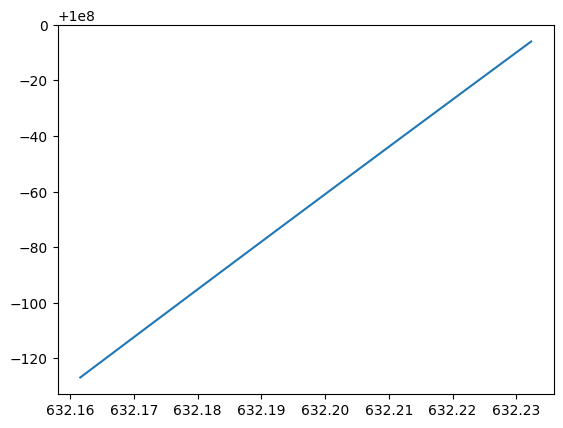

In [65]:
plt.plot(wls[16:24], length_real[16:24])

In [ ]:
# Definición de Parámetros del Bloque Principal (100 mm, Acero)
L_nominal = 100.0                       # [mm]
l_fit_medido = 100.0000299499           # [mm] Obtenido por EFSW script propio
alpha_acero = 11.5e-6                   # [K^-1] (Coeficiente típico para bloques de acero)
bloque_100mm = GaugeBlockLengthCorrection(nominal_length=L_nominal, expansion_coefficient=alpha_acero)

# Datos para el Experimento de Paquete (Cambio de Fase)
# Bloques: 2mm, 5mm, 8mm, 10mm (n = 4)
num_blocks = 4
# Longitudes ópticas individuales (simuladas con un ligero desvío por rugosidad/fase)
l_opt_ind = [2.000015, 5.000010, 8.000012, 10.000018] 
suma_l_opt_ind = sum(l_opt_ind) # 25.000055 mm

# Forzamos que la diferencia nos de un l_phi de -0.000025 mm (-25 nm)
# l_phi = (l_opt_pack - suma_l_opt_ind) / 3  => l_opt_pack = suma_l_opt_ind + (3 * -0.000025)
l_opt_pack = 24.999980 # mm

In [ ]:
# Correcciones a la longitud calculada por MEFSW


632.8729586541536